[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/01_ensemble_methods.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/01_ensemble_methods.ipynb)

# Ensemble Methods for Tabular Data

This notebook covers ensemble learning—from foundational concepts to practical implementations with Random Forests and Gradient Boosting.

## Learning Objectives

- Understand why single models fail and how ensembles help
- Learn voting and bagging as ensemble foundations
- Master Random Forests for tabular data
- Interpret feature importance
- Apply Gradient Boosting
- Know when to use tree-based methods vs neural networks

## 1. Why Ensembles?

Single models often fail because of:
- **High variance** → overfitting
- **High bias** → underfitting
- **Noise sensitivity**

**Core Idea:** Instead of trusting ONE model, combine MANY imperfect models.

If each model is better than random and makes different mistakes, combining them yields higher accuracy. This is called **error diversification**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"Training: {len(X_train)}, Validation: {len(X_valid)}")
X.head()

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Training: 16512, Validation: 4128


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 2. Decision Trees

A decision tree recursively splits data based on feature thresholds. Trees are powerful but **unstable**—small data changes can lead to large prediction changes.

In [3]:
# Train a single decision tree
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

print(f"Single Decision Tree (max_depth=5):")
print(f"  Train R²: {r2_score(y_train, tree.predict(X_train)):.4f}")
print(f"  Valid R²: {r2_score(y_valid, tree.predict(X_valid)):.4f}")

Single Decision Tree (max_depth=5):
  Train R²: 0.6377
  Valid R²: 0.5997


## 3. Simple Voting Ensemble

The simplest ensemble: train multiple models and average their predictions.

In [4]:
# Manual ensemble of trees
preds = []
for seed in range(20):
    t = DecisionTreeRegressor(max_depth=5, random_state=seed)
    t.fit(X_train, y_train)
    preds.append(t.predict(X_valid))

ensemble_pred = np.mean(preds, axis=0)
print(f"Simple Voting Ensemble R²: {r2_score(y_valid, ensemble_pred):.4f}")

Simple Voting Ensemble R²: 0.5997


## 4. Bagging (Bootstrap Aggregation)

Bagging improves stability by:
1. Sampling training data **with replacement** (bootstrap)
2. Training models on different samples
3. Averaging predictions

Each tree sees slightly different data and learns different patterns. When averaged, noise cancels out.

In [5]:
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bag.fit(X_train, y_train)

print(f"Bagging (50 trees) R²: {r2_score(y_valid, bag.predict(X_valid)):.4f}")

Bagging (50 trees) R²: 0.6469


## 5. Random Forests

Random Forests extend bagging by also using **random feature subsets** at each split. This further decorrelates the trees.

Key innovations (Breiman, 2001):
- Bootstrap samples
- Random feature selection at each split
- No pruning needed

In [6]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

print(f"Random Forest (100 trees, max_depth=10):")
print(f"  Train R²: {r2_score(y_train, rf.predict(X_train)):.4f}")
print(f"  Valid R²: {r2_score(y_valid, rf.predict(X_valid)):.4f}")
print(f"  Valid RMSE: {np.sqrt(mean_squared_error(y_valid, rf.predict(X_valid))):.4f}")

Random Forest (100 trees, max_depth=10):
  Train R²: 0.8555
  Valid R²: 0.7743
  Valid RMSE: 0.5438


## 6. Feature Importance

Random forests provide built-in feature importance scores based on how much each feature contributes to reducing prediction error.

In [7]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance Ranking:")
print(importance_df.to_string(index=False))

Feature Importance Ranking:
   feature  importance
    MedInc    0.604925
  AveOccup    0.139803
 Longitude    0.076487
  Latitude    0.076454
  HouseAge    0.047389
  AveRooms    0.028928
 AveBedrms    0.013018
Population    0.012995


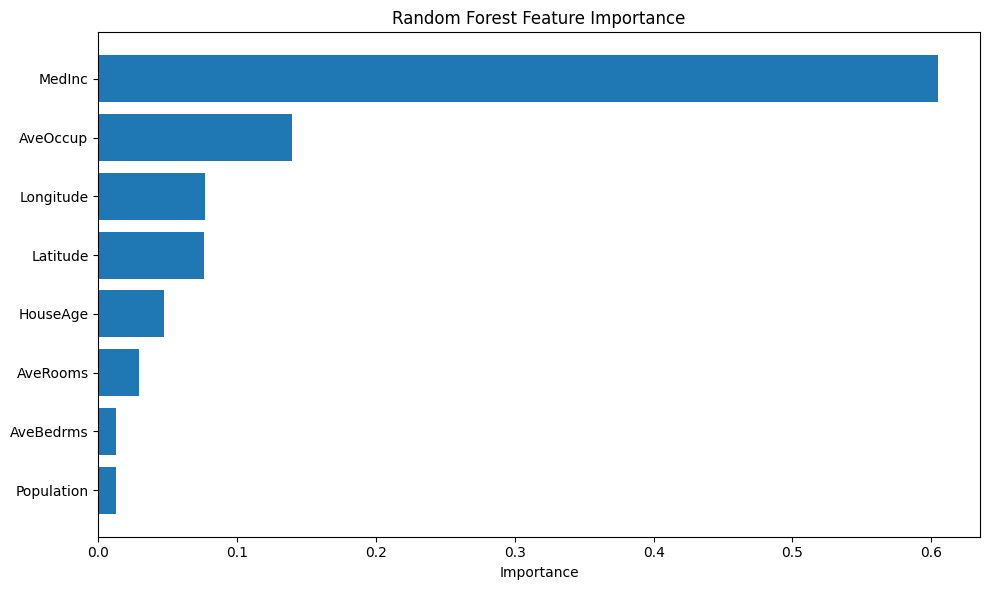

In [8]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning

| Parameter | Description | Typical Range |
|-----------|-------------|---------------|
| `n_estimators` | Number of trees | 100-1000 |
| `max_depth` | Maximum tree depth | 5-30 or None |
| `min_samples_leaf` | Minimum samples per leaf | 1-20 |
| `max_features` | Features per split | 'sqrt', 'log2' |

In [9]:
configs = [
    {'n_estimators': 50, 'max_depth': 5},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': 15},
]

print("Hyperparameter Comparison:")
print("-" * 50)
for config in configs:
    model = RandomForestRegressor(**config, min_samples_leaf=5, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    score = r2_score(y_valid, model.predict(X_valid))
    print(f"n_estimators={config['n_estimators']:3d}, max_depth={config['max_depth']:2d} -> R²: {score:.4f}")

Hyperparameter Comparison:
--------------------------------------------------
n_estimators= 50, max_depth= 5 -> R²: 0.6471
n_estimators=100, max_depth=10 -> R²: 0.7743
n_estimators=200, max_depth=15 -> R²: 0.7980


## 8. Gradient Boosting

While Random Forests train trees **in parallel**, Gradient Boosting trains trees **sequentially**—each tree corrects errors from previous trees.

Popular implementations: XGBoost, LightGBM, CatBoost.

In [10]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)

print(f"Gradient Boosting:")
print(f"  Valid R²: {r2_score(y_valid, gb.predict(X_valid)):.4f}")
print(f"  Valid RMSE: {np.sqrt(mean_squared_error(y_valid, gb.predict(X_valid))):.4f}")

Gradient Boosting:
  Valid R²: 0.8110
  Valid RMSE: 0.4977


## 9. Method Comparison

In [11]:
print("\nSummary Comparison:")
print("=" * 40)
print(f"Single Tree:       R² = {r2_score(y_valid, tree.predict(X_valid)):.4f}")
print(f"Bagging:           R² = {r2_score(y_valid, bag.predict(X_valid)):.4f}")
print(f"Random Forest:     R² = {r2_score(y_valid, rf.predict(X_valid)):.4f}")
print(f"Gradient Boosting: R² = {r2_score(y_valid, gb.predict(X_valid)):.4f}")


Summary Comparison:
Single Tree:       R² = 0.5997
Bagging:           R² = 0.6469
Random Forest:     R² = 0.7743
Gradient Boosting: R² = 0.8110


## 10. When to Use What

**Tree-based methods (Random Forest, XGBoost):**
- Structured/tabular data
- When interpretability matters
- Smaller datasets (< 100K rows)
- Fast iteration needed

**Neural networks:**
- Unstructured data (images, text, audio)
- Very large datasets
- Transfer learning available

## Exercises

1. **Overfitting curve**: Plot train vs validation R² for `max_depth` from 3 to 20.

2. **Out-of-bag score**: Set `oob_score=True` in RandomForest and compare with validation score.

3. **Try XGBoost**: Install with `pip install xgboost` and compare performance.

4. **Feature engineering**: Create `rooms_per_household = AveRooms / AveOccup` and measure impact.

## References

- Breiman, L. (2001). Random Forests. *Machine Learning*, 45, 5-32.
- [Fast.ai Lesson 6: Random Forests](https://course.fast.ai/Lessons/lesson6.html)
- [Fastbook Chapter 9: Tabular Modeling](https://github.com/fastai/fastbook/blob/master/09_tabular.ipynb)